In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from torch.utils.data import TensorDataset, DataLoader

## 1. Introduction

The objective is to detect the presence of exoplanets from stellar light curves using supervised machine learning.
When a planet transits in front of its star, it causes a periodic dip in the observed brightness. The task therefore framed a binary time-series classification.
- 0: No planet present
- 1: Planet present


## 2. Theoretical Background: Transit Method

The transit method detects exoplanets by measuring periodic
brightness dips caused when a planet passes in front of its star.

The approximate transit depth is proportional to:

    (Rp / Rs)^2

where,
Rp is the planet radius
Rs is the stellar radius

Transit duration and periodicity depend on orbital parameters
such as period and inclination.

In [2]:
def transit_curve(has_planet=True, n_points=200):
    time = np.linspace(0, 1, n_points)
    flux = np.ones_like(time)

    if has_planet:
        period = np.random.uniform(0.2, 0.4)
        depth = np.random.uniform(0.003, 0.02)
        duration = np.random.uniform(0.02, 0.06)

        t0 = np.random.uniform(0, period)

        for k in np.arange(t0, 1, period):
            mask = np.abs(time - k) < duration
            flux[mask] -= depth

    variability = 0.002 * np.sin(2 * np.pi * np.random.uniform(1, 3) * time)
    flux += variability

    noise = np.random.normal(0, 0.003, n_points)
    flux += noise

    return time, flux

## 3. Synthetic Data Generation

Synthetic transit curves were generated by simulating:
- Periodic brightness dips
- Randomized transit depth
- Randomized duration
- Randomized orbital period

To approximate real astronomical observations:
- Low-frequency stellar variability was added
- Gaussian noise was injected
- Each light curve was normalized per sample



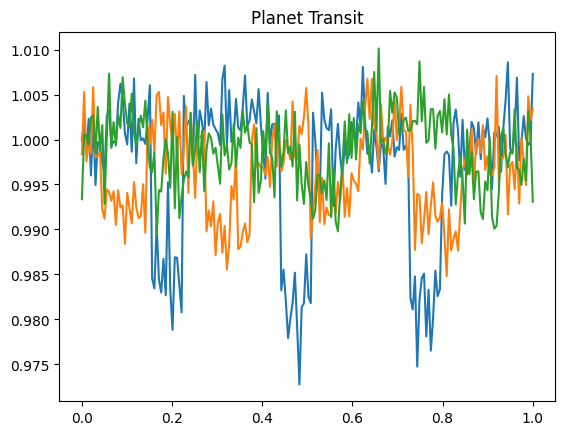

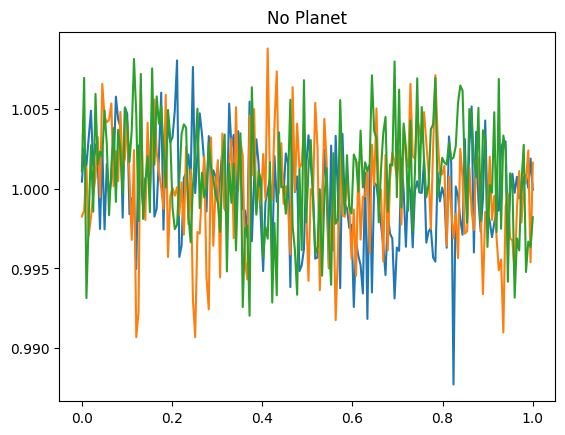

In [3]:
for i in range(3):
    t, f = transit_curve(has_planet=True)
    plt.plot(t, f)
plt.title("Planet Transit")
plt.show()

for i in range(3):
    t, f = transit_curve(has_planet=False)
    plt.plot(t, f)
plt.title("No Planet")
plt.show()

In [4]:
np.random.seed(42)
torch.manual_seed(42)

In [5]:
def create_dataset(n_samples=2000):
    X, y = [], []

    for _ in range(n_samples):
        label = np.random.choice([0, 1])
        _, flux = transit_curve(bool(label))

        flux = (flux - np.mean(flux)) / (np.std(flux) + 1e-8)

        X.append(flux)
        y.append(label)

    return np.array(X), np.array(y)

X, y = create_dataset(3000)
print(X.shape, y.shape)

(3000, 200) (3000,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.float32)

## 4. Model Architecture

A 1D Convolutional Neural Network (CNN) was used for classification.

1D CNNs are well-suited for time-series data because:
- Convolution layers detect localized temporal features
- Transit dips are localized in time
- The model is robust to small timing shifts

Adaptive average pooling was used to avoid assumptions
about intermediate feature dimensions.

In [7]:
class TransitCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, 5),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, 5),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

## 5. Training Procedure

The model was trained using:

- Binary Cross Entropy with Logits Loss
- Adam optimizer (learning rate = 0.001)
- Mini-batch training (batch size = 64)
- 80/20 train-test split

Training was performed for 20 epochs.

In [8]:
train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

model = TransitCNN()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(20):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb).squeeze()
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.5919
Epoch 2, Loss: 0.2788
Epoch 3, Loss: 0.1624
Epoch 4, Loss: 0.1459
Epoch 5, Loss: 0.1460
Epoch 6, Loss: 0.1345
Epoch 7, Loss: 0.1307
Epoch 8, Loss: 0.1175
Epoch 9, Loss: 0.1223
Epoch 10, Loss: 0.1309
Epoch 11, Loss: 0.1300
Epoch 12, Loss: 0.1179
Epoch 13, Loss: 0.1187
Epoch 14, Loss: 0.1161
Epoch 15, Loss: 0.1191
Epoch 16, Loss: 0.1178
Epoch 17, Loss: 0.1165
Epoch 18, Loss: 0.1147
Epoch 19, Loss: 0.1141
Epoch 20, Loss: 0.1192


## 6. Evaluation Metrics

Model performance was evaluated using:

- Receiver Operating Characteristic (ROC) curve
- Area Under the Curve (AUC)

ROC curves measure performance across different classification
thresholds, while AUC quantifies separability between classes.

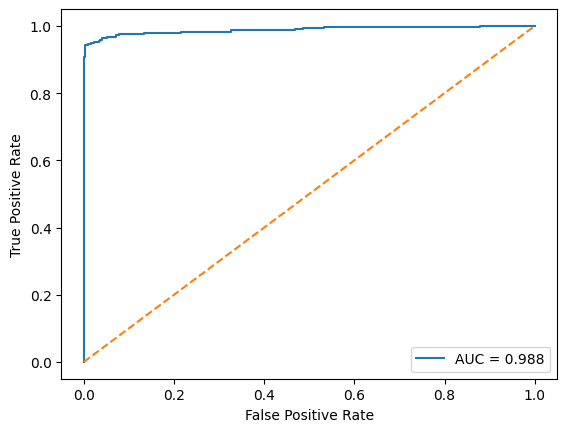

AUC: 0.9880730069805699


In [9]:
model.eval()
with torch.no_grad():
    logits = model(X_test).squeeze()
    probs = torch.sigmoid(logits).numpy()

fpr, tpr, _ = roc_curve(y_test.numpy(), probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("AUC:", roc_auc)

## 7. Results

The model achieved an AUC of approximately 0.99,
indicating strong separability between planetary and non-planetary light curves.

The high AUC suggests that the model successfully detects
transit morphology even under noisy conditions.

## 8. Conclusion

Real astronomical observations contain instrumental noise and
stellar variability. By including noise and variability in the
synthetic generator, the model was trained under realistic conditions.

This improves generalization and reduces the risk of
overfitting to idealized transit shapes.

Cloning into 'EXXA'...
remote: Enumerating objects: 165, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 165 (delta 1), reused 6 (delta 1), pack-reused 159 (from 2)
Receiving objects: 100% (165/165), 607.56 MiB | 26.10 MiB/s, done.
Resolving deltas: 100% (25/25), done.
Updating files: 100% (152/152), done.


In [22]:
# Copy the cleaned notebook again
import shutil
shutil.copy('/content/drive/MyDrive/Colab Notebooks/sequential_test.ipynb', '/content/EXXA/sequential_test.ipynb')

%cd /content/EXXA

# Amend the last commit (replaces it with clean version)
!git add .
!git commit --amend -m "Added sequential test notebook"
!git push origin main --force

/content/EXXA
hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> EXXA
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached EXXA
hint: 
hint: See "git help submodule" for more information.
[main b4bb669] Added sequential test notebook
 Date: Sat Mar 14 14:24:48 2026 +0000
 2 files changed, 2 insertions(+)
 create mode 160000 EXXA
 create mode 100644 sequential_test.ipynb
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 199.06 KiB | 3.83 MiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
remote: error: GH013: Repository rule violations found for